# 00 — Dataset Creation

Takes raw page images from `data/raw/` and produces a **class-balanced** orientation dataset.

## Pipeline per source image

```
source image
  └── × 4 rotations (0°, 90°, 180°, 270°)   ← guarantees 25% per class
        └── augment()                         ← scanner-realistic noise (applied equally to all classes)
              └── messify()                   ← randomly applied to ~40% of images
                    → saved to data/rotated/
```

### Messify transforms
Simulates real-world degraded scans from small orgs (cooperatives, NGOs, municipalities):

| Transform | Simulates |
|---|---|
| Page skew (±3°) | Scanner misalignment |
| Shadow gradient | Uneven lighting, book spine shadow |
| Ink bleed / dilation | Old inkjet or dot-matrix printing |
| Fold/crease line | Physical document folds |
| Salt & pepper noise | Dirty scanner glass |
| Low resolution blur | Phone-camera scans, fax |
| Heavy JPEG compression | WhatsApp-forwarded documents |

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from src.preprocess import rotate_image, DEGREES_TO_LABEL

RAW_DIR = Path('../data/raw')
OUT_DIR = Path('../data/rotated')
OUT_DIR.mkdir(parents=True, exist_ok=True)
Path('../results').mkdir(exist_ok=True)

EXTENSIONS  = {'.jpg', '.jpeg', '.png', '.tiff', '.bmp'}
MESSY_PROB  = 0.4   # 40% of images get the messify pass on top of augment

In [2]:
# ── Base augmentation (applied to ALL images equally) ─────────────────────────

rng = np.random.default_rng(seed=42)

def augment(img: np.ndarray) -> np.ndarray:
    """Scanner-realistic augmentation. Applied to every image regardless of class."""
    img = img.copy().astype(np.float32)

    # Brightness / contrast jitter
    alpha = rng.uniform(0.85, 1.15)
    beta  = float(rng.integers(-15, 15))
    img   = np.clip(img * alpha + beta, 0, 255)

    # Gaussian noise
    img = np.clip(img + rng.normal(0, rng.uniform(1, 6), img.shape), 0, 255)
    img = img.astype(np.uint8)

    # Slight crop + resize (scan misalignment ±2%)
    h, w = img.shape[:2]
    t = rng.integers(0, max(1, int(h * 0.02)))
    b = rng.integers(0, max(1, int(h * 0.02)))
    l = rng.integers(0, max(1, int(w * 0.02)))
    r = rng.integers(0, max(1, int(w * 0.02)))
    img = cv2.resize(img[t:h-b, l:w-r], (w, h), interpolation=cv2.INTER_LINEAR)

    # JPEG compression
    q = int(rng.integers(70, 95))
    _, enc = cv2.imencode('.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, q])
    return cv2.imdecode(enc, cv2.IMREAD_COLOR)

In [3]:
# ── Messify (applied to ~40% of images) ──────────────────────────────────────
# Simulates degraded real-world scans from small Nepali orgs.
# Each transform is independently probabilistic so combinations vary.

def messify(img: np.ndarray) -> np.ndarray:
    img = img.copy()
    h, w = img.shape[:2]

    # 1. Page skew ±3°  (scanner misalignment)
    if rng.random() < 0.5:
        angle = rng.uniform(-3, 3)
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_REPLICATE)

    # 2. Shadow gradient  (book spine / uneven lamp)
    if rng.random() < 0.4:
        direction = rng.choice(['left', 'right', 'top', 'bottom'])
        shadow_strength = rng.uniform(0.3, 0.6)   # darken by up to 60%
        shadow_width    = rng.uniform(0.2, 0.5)   # covers 20-50% of the page
        mask = np.ones((h, w), dtype=np.float32)
        if direction == 'left':
            end = int(w * shadow_width)
            mask[:, :end] = np.linspace(1 - shadow_strength, 1, end)
        elif direction == 'right':
            start = int(w * (1 - shadow_width))
            mask[:, start:] = np.linspace(1, 1 - shadow_strength, w - start)
        elif direction == 'top':
            end = int(h * shadow_width)
            mask[:end, :] = np.linspace(1 - shadow_strength, 1, end).reshape(-1, 1)
        else:
            start = int(h * (1 - shadow_width))
            mask[start:, :] = np.linspace(1, 1 - shadow_strength, h - start).reshape(-1, 1)
        img = np.clip(img.astype(np.float32) * mask[:, :, np.newaxis], 0, 255).astype(np.uint8)

    # 3. Ink bleed / dilation  (old inkjet / dot-matrix)
    if rng.random() < 0.3:
        k = int(rng.choice([2, 3]))
        kernel = np.ones((k, k), np.uint8)
        img = cv2.dilate(img, kernel, iterations=1)

    # 4. Fold / crease line
    if rng.random() < 0.3:
        fold_axis = rng.choice(['h', 'v'])
        if fold_axis == 'h':
            y = int(rng.integers(h // 4, 3 * h // 4))
            img[y-1:y+2, :] = np.clip(
                img[y-1:y+2, :].astype(np.float32) * rng.uniform(0.5, 0.75), 0, 255
            ).astype(np.uint8)
        else:
            x = int(rng.integers(w // 4, 3 * w // 4))
            img[:, x-1:x+2] = np.clip(
                img[:, x-1:x+2].astype(np.float32) * rng.uniform(0.5, 0.75), 0, 255
            ).astype(np.uint8)

    # 5. Salt & pepper noise  (dirty scanner glass)
    if rng.random() < 0.4:
        amount = rng.uniform(0.002, 0.01)
        n_pixels = int(amount * h * w)
        # salt
        ys = rng.integers(0, h, n_pixels)
        xs = rng.integers(0, w, n_pixels)
        img[ys, xs] = 255
        # pepper
        ys = rng.integers(0, h, n_pixels)
        xs = rng.integers(0, w, n_pixels)
        img[ys, xs] = 0

    # 6. Blur (low-res phone scan / fax)
    if rng.random() < 0.35:
        k = int(rng.choice([3, 5]))
        img = cv2.GaussianBlur(img, (k, k), 0)

    # 7. Heavy JPEG compression  (WhatsApp-forwarded docs)
    if rng.random() < 0.3:
        q = int(rng.integers(20, 50))
        _, enc = cv2.imencode('.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, q])
        img = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    return img

print('augment() and messify() ready.')

augment() and messify() ready.


In [4]:
source_images = [p for p in RAW_DIR.iterdir() if p.suffix.lower() in EXTENSIONS]
print(f'Source images : {len(source_images)}')
print(f'Expected total: {len(source_images) * 4} images (4 orientations × {len(source_images)} sources)')

Source images : 138
Expected total: 552 images (4 orientations × 138 sources)


In [5]:
records = []

for img_path in tqdm(source_images, desc='Building dataset'):
    for degrees in [0, 90, 180, 270]:
        rotated   = rotate_image(img_path, degrees)
        processed = augment(rotated)
        is_messy  = rng.random() < MESSY_PROB
        if is_messy:
            processed = messify(processed)

        out_path = OUT_DIR / f'{img_path.stem}_rot{degrees}.png'
        cv2.imwrite(str(out_path), processed)

        records.append({
            'image_path': str(out_path.resolve()),
            'label':      DEGREES_TO_LABEL[degrees],
            'degrees':    degrees,
            'source':     img_path.name,
            'messy':      is_messy,
        })

df = pd.DataFrame(records)
df.to_csv(Path('../data/dataset.csv'), index=False)
print(f'Dataset saved → data/dataset.csv  ({len(df)} rows)')
print(f'Messy images  : {df["messy"].sum()} ({df["messy"].mean()*100:.0f}%)')

Building dataset:   0%|          | 0/138 [00:00<?, ?it/s]

Building dataset:   1%|          | 1/138 [00:00<01:19,  1.72it/s]

Building dataset:   1%|▏         | 2/138 [00:01<01:16,  1.77it/s]

Building dataset:   2%|▏         | 3/138 [00:01<01:14,  1.81it/s]

Building dataset:   3%|▎         | 4/138 [00:02<01:15,  1.78it/s]

...

Building dataset:  99%|█████████▊| 136/138 [01:15<00:01,  1.83it/s]

Building dataset:  99%|█████████▉| 137/138 [01:16<00:00,  1.76it/s]

Building dataset: 100%|██████████| 138/138 [01:16<00:00,  1.75it/s]

Building dataset: 100%|██████████| 138/138 [01:16<00:00,  1.80it/s]

Dataset saved → data/dataset.csv  (552 rows)
Messy images  : 210 (38%)


/var/folders/ks/2hntfc9531d20w4m1bjd8w400000gn/T/ipykernel_77171/977902811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x='degrees', y='count', ax=ax,


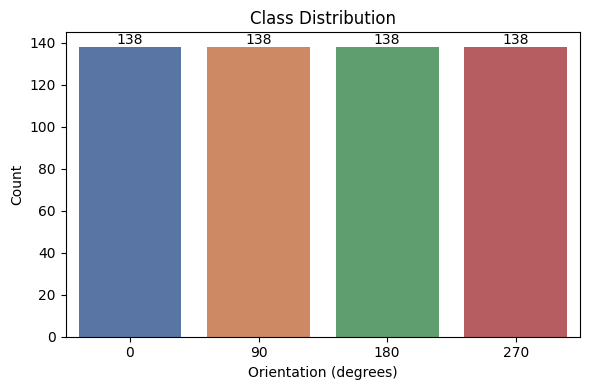

Classes balanced.


In [6]:
# ── Class balance check ───────────────────────────────────────────────────────
counts = df.groupby('degrees').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=counts, x='degrees', y='count', ax=ax,
            palette=['#4C72B0','#DD8452','#55A868','#C44E52'])
ax.set_title('Class Distribution')
ax.set_xlabel('Orientation (degrees)')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig(Path('../results/class_distribution.png'), dpi=150)
plt.show()

assert counts['count'].nunique() == 1, 'Classes NOT balanced!'
print('Classes balanced.')

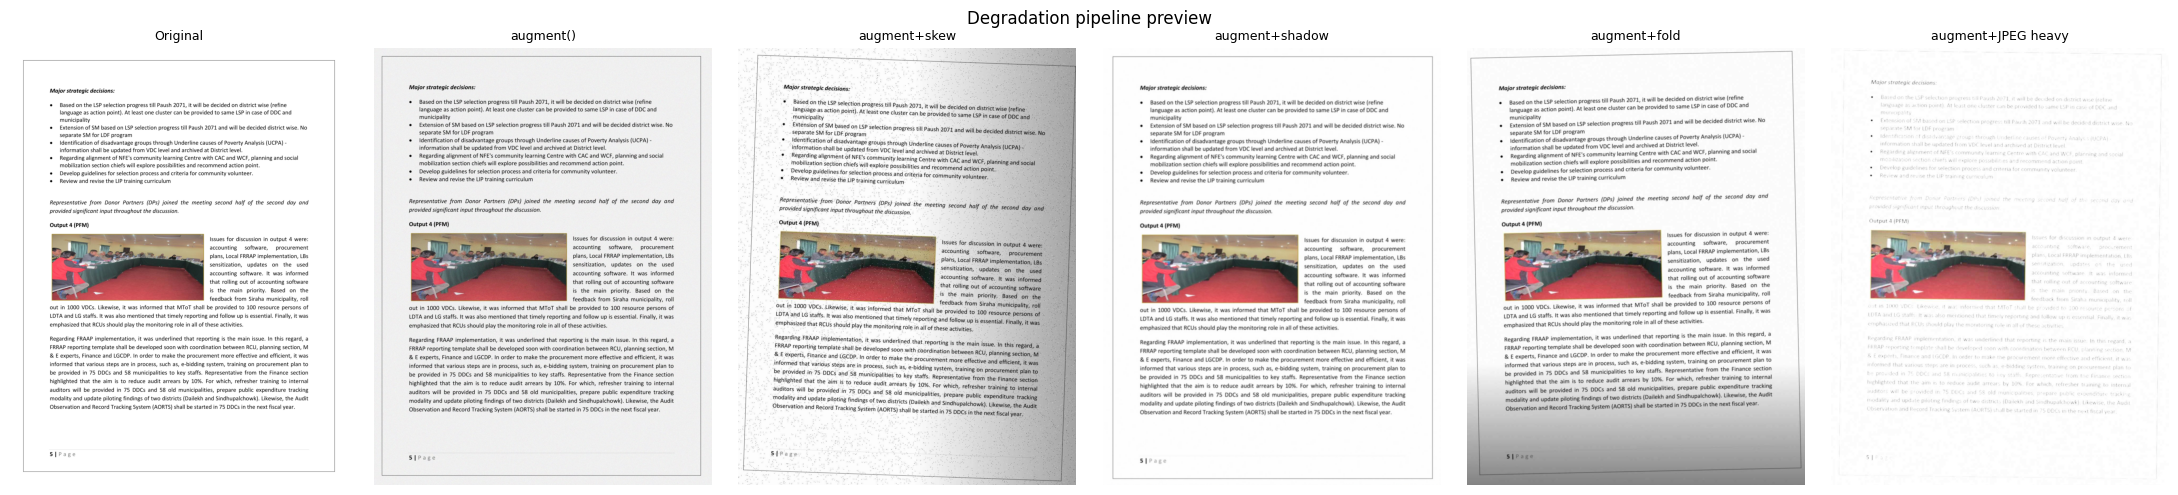

In [7]:
# ── Visual check: clean vs messy side by side ─────────────────────────────────
sample_src = source_images[0]
base = rotate_image(sample_src, 0)

examples = [
    ('Original',          base),
    ('augment()',         augment(base.copy())),
    ('augment+skew',      messify(augment(base.copy()))),
    ('augment+shadow',    messify(augment(base.copy()))),
    ('augment+fold',      messify(augment(base.copy()))),
    ('augment+JPEG heavy',messify(augment(base.copy()))),
]

fig, axes = plt.subplots(1, 6, figsize=(22, 5))
for ax, (title, img) in zip(axes, examples):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.suptitle('Degradation pipeline preview', fontsize=12)
plt.tight_layout()
plt.savefig(Path('../results/messify_preview.png'), dpi=150)
plt.show()

In [8]:
print('=== Dataset Summary ===')
print(f'Total images   : {len(df)}')
print(f'Per class      : {len(df) // 4}')
print(f'Messy images   : {df["messy"].sum()} ({df["messy"].mean()*100:.0f}%)')
print(f'Unique sources : {df["source"].nunique()}')

=== Dataset Summary ===
Total images   : 552
Per class      : 138
Messy images   : 210 (38%)
Unique sources : 138
